In [1]:
import sys
sys.path.append('../')

In [2]:
%reload_ext autoreload
%autoreload 2

from libs.utils.ios import path_join
from libs.utils.config_loader import combine_model, load_payoffs, load_prior
from libs.simulation.simulator import DataSimulator
from libs.simulation.simulator import summarize_results, results_to_latex, summarize_decisions, decisions_to_latex
from libs.simulation.simulator import top_of_range_threshold
from libs.visualization import plots

In [3]:
ROOT = '../../'
PLOTS_DIR = path_join(ROOT, 'results/plots')

In [4]:
NETWORK_MIN = 10
NON_NETWORK_MIN = {'n_citations':None, 'n_publications':None, 'h_index':None}
TOP_K_CORNER = 20

In [5]:
plots.set_paper_style()

In [6]:
n_candidates = 1000
seed = 123456789
prior_path = '../../config/prior/main_paper.yaml'
net_path = '../../config/network/main_paper.yaml'
payoff_path = '../../config/payoffs/main_paper.yaml'
nn_paths = {'n_citations':'../../config/non_network/main_paper.yaml',
            'n_publications':'../../config/non_network/poisson.yaml',
            'h_index':'../../config/non_network/power_law.yaml',
            }

payoff_matrix = load_payoffs(payoff_path)
results = {}
models = {}

for nn_name, nn_path in nn_paths.items():
    prior_good = load_prior(prior_path)
    model = combine_model(
        prior_good,
        network=net_path,
        non_network=nn_path,
    )
    n_name = model.get_signals_by_type("network")[0].name

    sim = DataSimulator(model=model,
                        n_candidates=n_candidates,
                        seed=seed,
                        payoff_matrix=payoff_matrix,
                        )
    r = sim.simulate(top_k=TOP_K_CORNER)
    results[(n_name,nn_name)]= r
    models[(n_name,nn_name)] = model
    


In [7]:
df_results = summarize_results(results).round(2)
display(df_results)

,network_signal,nn_name,accuracy_posterior,accuracy_payoff,precision_posterior,precision_payoff,recall_posterior,recall_payoff,threshold_posterior,threshold_payoff,...,recall_topk,top_k,n_candidates,seed,network_signal_accuracy_posterior,non_network_signal_accuracy_posterior,network_signal_accuracy_payoff,non_network_signal_accuracy_payoff,network_signal_accuracy_topk,non_network_signal_accuracy_topk
0,referral_quality,n_citations,1.00,0.99,0.99,0.99,0.99,0.99,0.5,0.33,...,0.01,20,1000,123456789,0.96,0.97,0.96,0.97,0.89,0.66
1,referral_quality,n_publications,1.00,1.00,1.00,1.00,1.00,1.00,0.5,0.33,...,0.02,20,1000,123456789,0.96,0.99,0.96,0.99,0.89,0.67
2,referral_quality,h_index,0.96,0.96,0.93,0.92,0.94,0.96,0.5,0.33,...,0.00,20,1000,123456789,0.96,0.69,0.96,0.63,0.89,0.65


In [8]:
display(df_results[['network_signal','nn_name','accuracy_topk','precision_topk','recall_topk']])

,network_signal,nn_name,accuracy_topk,precision_topk,recall_topk
0,referral_quality,n_citations,0.66,1.0,0.01
1,referral_quality,n_publications,0.66,1.0,0.02
2,referral_quality,h_index,0.65,1.0,0.00


In [9]:
print(results_to_latex(df_results))

\begin{table}[ht]
\centering
\begin{tabular}{lccccc}
\toprule
{Observed signals} & {Accuracy$\uparrow$} & {Precision$\uparrow$} & {Recall$\uparrow$} & {1D Accuracy ratio} & {Realized$\downarrow$} \\
(net., non-net.) & post.\ / pay.\ / topk & post.\ / pay.\ / topk & post.\ / pay.\ / topk & post.\ / pay.\ / topk & payoff \\
\midrule
referral\_quality, n\_citations & \textbf{1.00} / 0.99 / \textbf{0.66} & 0.99 / 0.99 / \textbf{1.00} & 0.99 / 0.99 / 0.01 & 0.99 / 0.99 / \textbf{1.35} & $-$450 \\
referral\_quality, n\_publications & \textbf{1.00} / \textbf{1.00} / \textbf{0.66} & \textbf{1.00} / \textbf{1.00} / \textbf{1.00} & \textbf{1.00} / \textbf{1.00} / \textbf{0.02} & 0.97 / 0.97 / \textbf{1.33} & \textbf{$-$150} \\
referral\_quality, h\_index & 0.96 / 0.96 / 0.65 & 0.93 / 0.92 / \textbf{1.00} & 0.94 / 0.96 / 0.00 & \textbf{1.39} / \textbf{1.52} / \textbf{1.37} & $-$2,700 \\
\bottomrule
\end{tabular}
\caption{1D Accuracy ratio shows the ratio of network to non-network individual signa

/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/inference/signal.py:64: RuntimeWarning: invalid value encountered in subtract
  self.likelihood_good.log_prob(x)
/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1847: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1847: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/Users/espinl/Documents/CODE/NetworkFairness_Perspective/code/notebooks/../libs/visualization/plots.py:1847: UserWarning: You passed a edgecolor/edgecolors ('white') for an un

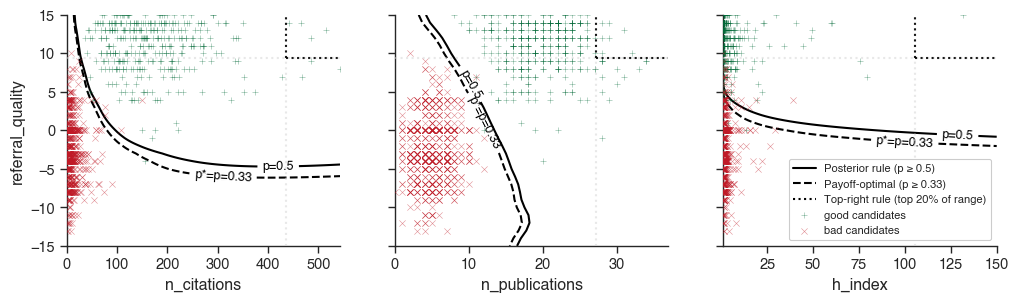

Saved figure to ../../results/plots/decision_boundaries.pdf


In [10]:
fig, panels = plots.create_panel_figure([1,1,1], 
                                        figsize=(12, 3),
                                        width_ratios=[0.33, 0.33, 0.33],
                                        wspace=0.2,
                                        panel_labels=None,
                                        )

for i, (key, result) in enumerate(results.items()):
    n_name, nn_name = key

    # simulated data
    is_good = result.true_states == "good"
    obs_non = result.observations[nn_name]
    obs_net = result.observations[n_name]
    scatter = [
            {"x": obs_non[is_good], "y": obs_net[is_good], "color": plots.COLOR_GOOD, "label": "good candidates", 'marker':'+'},
            {"x": obs_non[~is_good], "y": obs_net[~is_good], "color": plots.COLOR_BAD, "label": "bad candidates", 'marker':'x'},
        ]

    # boundaries
    boundaries = [
        {"level": 0.5, "linestyle": "solid", "label": "Posterior rule (p \u2265 0.5)", "fmt": "p=%.1f", 'linewidth':1.5},
    ]
    if payoff_matrix is not None:
        pstar = payoff_matrix.optimal_threshold()
        if 0 < pstar < 1:
            boundaries.append({
                "level": pstar,
                "linestyle": "dashed",
                "label": f"Payoff-optimal (p \u2265 {pstar:.2f})",
                "fmt": "p*=p=%.2f",
                'linewidth':1.5
            })
            
    # top right corner
    x_min = top_of_range_threshold(obs_non, TOP_K_CORNER)
    y_min = top_of_range_threshold(obs_net, TOP_K_CORNER)
    NETWORK_MIN = y_min
    NON_NETWORK_MIN[nn_name] = x_min
    region_boxes=[{
        "x_min": x_min,
        "y_min": y_min,
        "color": "black",
        "linestyle": "dotted",
        'linewidth':1.5,
        "label": f"Top-right rule (top 20% of range)",
    }]

    # plot
    ax = panels[i][0]
    model = models[(n_name,nn_name)]
    plots.plot_posterior_heatmap_network_nonnetwork(
            model,
            ax=ax,
            n_x=120,
            n_y=120,
            gaussian_sigma=1.5,
            decision_boundaries=boundaries,
            scatter_data=scatter,
            region_boxes=region_boxes,
            aesthetics={
                "title": None,

                'show_ylabel': i == 0,
                'show_ytickslabels': i==0,

                'show_legend': nn_name == 'h_index',
                'show_heatmap': False
            },
        )

fig.tight_layout()
fn = path_join(PLOTS_DIR, f'decision_boundaries.pdf')
plots.save_fig(fig, fn)
    


In [11]:
df_decisions = summarize_decisions(results, network_min=NETWORK_MIN, non_network_min=NON_NETWORK_MIN).round(2)
display(df_decisions)

,n_name,nn_name,inside_top_right,outside_top_right,inside_posterior,outside_posterior,inside_payoff,outside_payoff
0,referral_quality,n_citations,4,996,350,650,352,648
1,referral_quality,n_publications,7,993,349,651,349,651
2,referral_quality,h_index,1,999,351,649,364,636


In [12]:
print(decisions_to_latex(df_decisions))

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
Observed signals & Posterior-based & Payoff-based & Top-right rule \\
(net., non-net.) & good / bad & good / bad & good / bad \\
\midrule
referral\_quality, n\_citations & 350 / 650 & 352 / 648 & 4 / 996 \\
referral\_quality, n\_publications & 349 / 651 & 349 / 651 & 7 / 993 \\
referral\_quality, h\_index & 351 / 649 & 364 / 636 & 1 / 999 \\
\bottomrule
\end{tabular}
\end{table}


In [13]:
NETWORK_MIN

9.399999999999999

In [14]:
NON_NETWORK_MIN

{'n_citations': 435.08439247383546,
 'n_publications': 27.2,
 'h_index': 105.38132653001152}